In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# split data into train & test
from sklearn.model_selection import train_test_split
# import linear regression & model evaluation
from sklearn.linear_model import LinearRegression

# Disable Warnings
import warnings
warnings.filterwarnings('ignore')


## READ DATASET

In [87]:
house_data = pd.read_csv("D:\AI_Training\house_sales_data.csv")

## BASIC METHODS head(), columns(),shape(), check-null & info()

In [88]:
house_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [89]:
# shape = (rows, columns)
house_data.shape

(21613, 21)

In [90]:
house_data.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [91]:
# Show the distribution of data using .describe()
house_data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Assumptions of Linear Regression
Is Label Normally Distributed ?

<Axes: xlabel='price', ylabel='Density'>

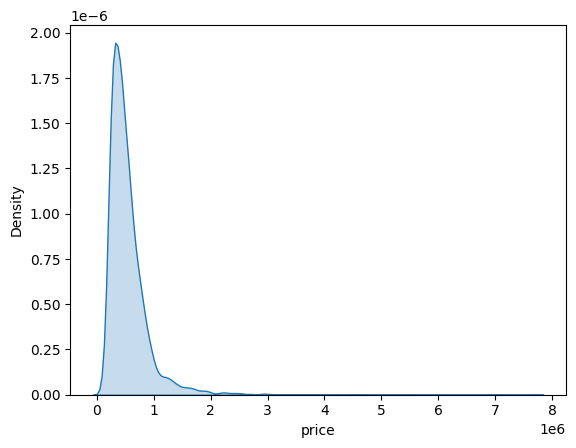

In [92]:
# KDE - Kernel Density Estimator - Plot to visualize house price
sns.kdeplot(house_data['price'], fill = True)

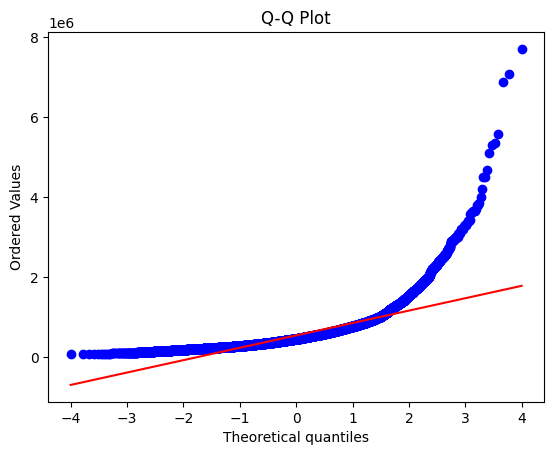

In [93]:
# Q-Q Plot
from scipy.stats import probplot
probplot(house_data['price'], dist = "norm", plot = plt)
plt.title('Q-Q Plot')
plt.show()

<Axes: xlabel='price'>

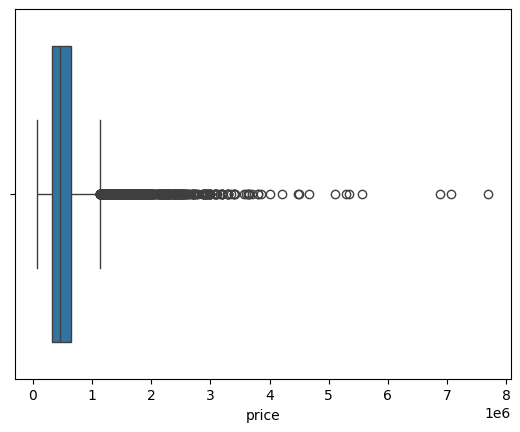

In [94]:
sns.boxplot(x = 'price', data = house_data)

In [95]:
# First Quartile Value
Q1 = house_data['price'].quantile(0.25)
# Third Quartile Value
Q3 = house_data['price'].quantile(0.75)

In [96]:
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [97]:
def outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return outliers

In [98]:
house_data.info(['price'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [99]:
outliers_iqr(house_data, 'price')

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
21,2524049179,20140826T000000,2000000.0,3,2.75,3050,44867,1.0,0,4,...,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336
49,822039084,20150311T000000,1350000.0,3,2.50,2753,65005,1.0,1,2,...,9,2165,588,1953,0,98070,47.4041,-122.451,2680,72513
69,1802000060,20140612T000000,1325000.0,5,2.25,3200,20158,1.0,0,0,...,8,1600,1600,1965,0,98004,47.6303,-122.215,3390,20158
125,4389200955,20150302T000000,1450000.0,4,2.75,2750,17789,1.5,0,0,...,8,1980,770,1914,1992,98004,47.6141,-122.212,3060,11275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21568,524059330,20150130T000000,1700000.0,4,3.50,3830,8963,2.0,0,0,...,10,3120,710,2014,0,98004,47.5990,-122.197,2190,10777
21576,9253900271,20150107T000000,3567000.0,5,4.50,4850,10584,2.0,1,4,...,10,3540,1310,2007,0,98008,47.5943,-122.110,3470,18270
21590,7430200100,20140514T000000,1222500.0,4,3.50,4910,9444,1.5,0,0,...,11,3110,1800,2007,0,98074,47.6502,-122.066,4560,11063
21597,191100405,20150421T000000,1575000.0,4,3.25,3410,10125,2.0,0,0,...,10,3410,0,2007,0,98040,47.5653,-122.223,2290,10125


In [100]:
print(lower_bound, upper_bound)

-162625.0 1129575.0


In [101]:
outliers_iqr(house_data, 'price')

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
21,2524049179,20140826T000000,2000000.0,3,2.75,3050,44867,1.0,0,4,...,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336
49,822039084,20150311T000000,1350000.0,3,2.50,2753,65005,1.0,1,2,...,9,2165,588,1953,0,98070,47.4041,-122.451,2680,72513
69,1802000060,20140612T000000,1325000.0,5,2.25,3200,20158,1.0,0,0,...,8,1600,1600,1965,0,98004,47.6303,-122.215,3390,20158
125,4389200955,20150302T000000,1450000.0,4,2.75,2750,17789,1.5,0,0,...,8,1980,770,1914,1992,98004,47.6141,-122.212,3060,11275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21568,524059330,20150130T000000,1700000.0,4,3.50,3830,8963,2.0,0,0,...,10,3120,710,2014,0,98004,47.5990,-122.197,2190,10777
21576,9253900271,20150107T000000,3567000.0,5,4.50,4850,10584,2.0,1,4,...,10,3540,1310,2007,0,98008,47.5943,-122.110,3470,18270
21590,7430200100,20140514T000000,1222500.0,4,3.50,4910,9444,1.5,0,0,...,11,3110,1800,2007,0,98074,47.6502,-122.066,4560,11063
21597,191100405,20150421T000000,1575000.0,4,3.25,3410,10125,2.0,0,0,...,10,3410,0,2007,0,98040,47.5653,-122.223,2290,10125


In [102]:
# handling outliers by capping
# handling ouliers by median
house_data['price'] = house_data['price'].clip(lower = lower_bound, upper = upper_bound)

In [103]:
# handling outliers by capping or by median
house_data['price'] = house_data['price'].clip(lower = lower_bound, upper = upper_bound)

<Axes: xlabel='price'>

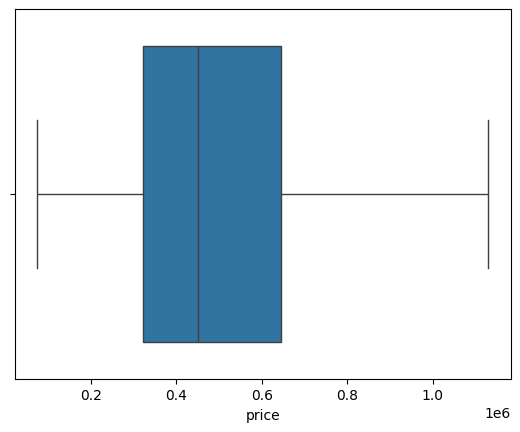

In [104]:
sns.boxplot(x = 'price', data = house_data)

<Axes: xlabel='price', ylabel='Density'>

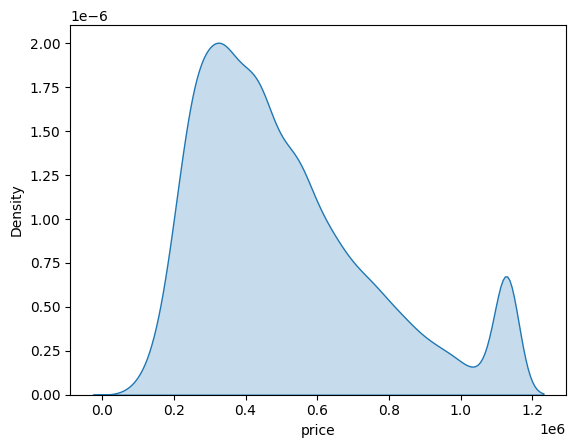

In [105]:
# KDE - Kernel Density Estimator - Plot to visualize house price
sns.kdeplot(house_data['price'], fill = True)

## Test for Multi-collinearity

VIF - Variance Inflation Factor is statistical measure used in regression analysis to detect multi-collinearity among independent variables (features)

In [106]:
x = house_data.drop(['id', 'date', 'price'], axis = 1)

In [ ]:
# !pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [109]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

In [110]:
vif_data

,feature,VIF
0,bedrooms,1.652063e+00
1,bathrooms,3.350562e+00
2,sqft_living,1.000800e+15
3,sqft_lot,2.102522e+00
4,floors,2.011907e+00
5,waterfront,1.203766e+00
6,view,1.435160e+00
7,condition,1.249475e+00
8,grade,3.417046e+00
9,sqft_above,1.000800e+15


In [111]:
# to check inflation factor coming infinite or not, we can use np.isinf() function to check if any value is infinite or not. If any value is infinite, we can drop that column from the dataset.
# display them

vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_data['VIF'] = vif_data['VIF'].replace([np.inf, -np.inf], np.nan)
vif_data = vif_data.dropna()

In [112]:
# Import required libraries
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


# ---------------------------------------------------------
# STEP 1: Select the independent variables (X)
# ---------------------------------------------------------

# Example:
# Suppose house_data is your original dataset
# Remove the target/dependent variable 'price'

x = house_data.drop('price', axis=1)


# ---------------------------------------------------------
# STEP 2: Keep only numerical columns
# ---------------------------------------------------------

x = x.select_dtypes(include=np.number)


# ---------------------------------------------------------
# STEP 3: Create VIF DataFrame
# ---------------------------------------------------------

vif_data = pd.DataFrame()

# Store column/feature names
vif_data['Feature'] = x.columns


# ---------------------------------------------------------
# STEP 4: Calculate VIF for every feature
# ---------------------------------------------------------

vif_data['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(len(x.columns))
]


# ---------------------------------------------------------
# STEP 5: Display VIF values
# ---------------------------------------------------------

print("VIF before handling infinite values:")
print(vif_data)


# ---------------------------------------------------------
# STEP 6: Replace infinite VIF values with NaN
# ---------------------------------------------------------

vif_data['VIF'] = vif_data['VIF'].replace(
    [np.inf, -np.inf],
    np.nan
)


# ---------------------------------------------------------
# STEP 7: Display features having infinite VIF
# ---------------------------------------------------------

print("\nFeatures with infinite VIF:")
print(vif_data[vif_data['VIF'].isna()])


# ---------------------------------------------------------
# STEP 8: Remove rows having NaN VIF
# ---------------------------------------------------------

vif_data = vif_data.dropna()


# ---------------------------------------------------------
# STEP 9: Display final VIF table
# ---------------------------------------------------------

print("\nVIF after removing infinite values:")
print(vif_data)

VIF before handling infinite values:
          Feature           VIF
0              id  1.028200e+00
1        bedrooms  1.652064e+00
2       bathrooms  3.350798e+00
3     sqft_living  1.000800e+15
4        sqft_lot  2.108391e+00
5          floors  2.012031e+00
6      waterfront  1.203819e+00
7            view  1.436291e+00
8       condition  1.250019e+00
9           grade  3.418450e+00
10     sqft_above  1.000800e+15
11  sqft_basement  1.000800e+15
12       yr_built  2.430915e+00
13   yr_renovated  1.150890e+00
14        zipcode  1.662181e+00
15            lat  1.180852e+00
16           long  1.831148e+00
17  sqft_living15  2.979822e+00
18     sqft_lot15  2.146292e+00

Features with infinite VIF:
Empty DataFrame
Columns: [Feature, VIF]
Index: []

VIF after removing infinite values:
          Feature           VIF
0              id  1.028200e+00
1        bedrooms  1.652064e+00
2       bathrooms  3.350798e+00
3     sqft_living  1.000800e+15
4        sqft_lot  2.108391e+00
5          floo

1 : No Multi-Collinearity
1-5 : Acceptable range for No Multi-Collinearity
5-10 : High Multi-Collinearity
'>10' : Very High Multi-Collinearity

In [113]:
## Features & Target

## 5 Features & Target

In [114]:
X = house_data.drop(['price','id','date','sqft_living','sqft_above','sqft_basement','zipcode'], axis = 1)

In [115]:
Y = house_data ['price']

## 6 Train & Test Split

In [116]:
# test_size = 0.2 (80% training set & 20% test_set)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

## 7. linear regression

In [117]:
lin_reg = LinearRegression()
# train linear regression model
lin_reg.fit(x_train, y_train)

LinearRegression()

In [118]:
# Test Score - (R2-Score: ranges between 0 to 1)
lin_reg.score(x_test, y_test)

0.7410238695114426

R2 (coefficient of determination): Tells how much of Taget varible's variability is measure or explained by model.

## 8.Performance Metrics

In [119]:
# R-squared - tell us the proportion of the variance in the dependent variable that is predictable from the independent variable(s)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.7410238695114426

In [120]:
y_pred = lin_reg.predict(x_test)

In [121]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# mean squared error
mse = mean_squared_error(y_test, y_pred)
print(mse)

 

16392328781.987694


In [122]:
# root mean squared error - RMSE
rmse = np.sqrt(mse)
print(rmse)

128032.53017099871


In [123]:

mae = mean_absolute_error(y_test, y_pred)
print(mae)

95850.58378811166


In [124]:
# root mean squared error - RMSE
rmse = np.sqrt(mse)
print(rmse)

128032.53017099871


In [125]:
# MAPE - tell us the average percentage error made by a forecasting / regression model compared to actual value

mape = mean_absolute_percentage_error(y_test, y_pred)
print(mape)

0.21259411919105647


## 9. Regression Plot

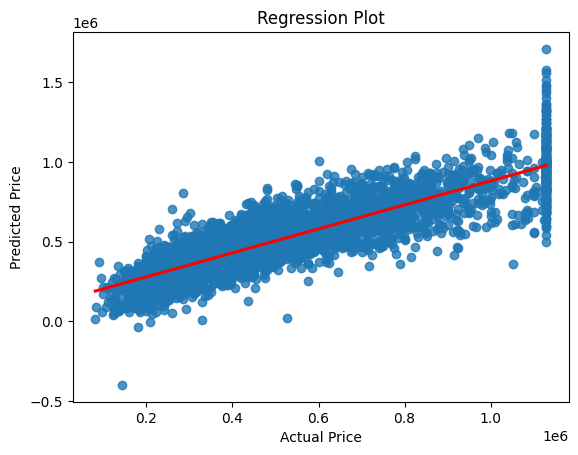

In [127]:
sns.regplot(x = y_test, y = y_pred, ci = None, line_kws={'color':'red'})
plt.title('Regression Plot')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

## Linear Regression Assumption - Is there Normality in Residual

In [128]:
residuals = y_test - y_pred

<Axes: xlabel='price', ylabel='Count'>

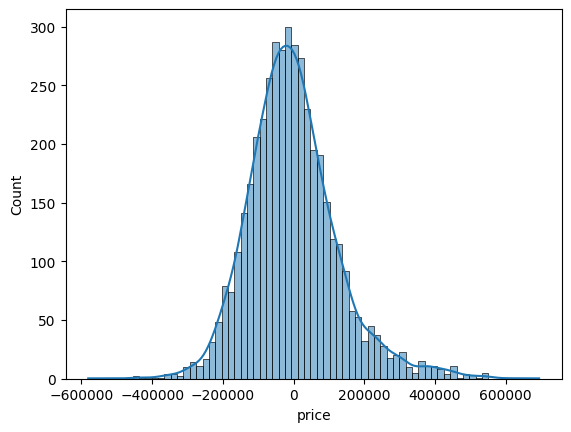

In [129]:
sns.histplot(residuals, kde = True)

## 10. Save the model & make predictions

In [130]:
lin_reg.intercept_

np.float64(-27180811.93772056)

In [131]:
lin_reg.coef_

array([ 6.46881102e+03,  5.30631560e+04,  2.64657516e-01,  2.87343879e+04,
        1.08892687e+05,  3.26003432e+04,  3.05194297e+04,  9.56314458e+04,
       -1.99434620e+03,  2.32864656e+01,  5.40708701e+05, -3.85570816e+04,
        8.49285604e+01, -8.47878343e-02])

In [132]:
x_train.columns

Index(['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'yr_built', 'yr_renovated', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [133]:
import joblib
# save the model
joblib.dump(lin_reg, 'linear_regression.pkl')

['linear_regression.pkl']

In [134]:
model = joblib.load('linear_regression.pkl')

In [135]:
print(x_test.sample(1))
model.predict(x_test.sample(1))

       bedrooms  bathrooms  sqft_lot  floors  waterfront  view  condition  \
10902         3        2.5      4244     2.0           0     0          3   

       grade  yr_built  yr_renovated      lat     long  sqft_living15  \
10902      8      2011             0  47.7057 -122.112           2690   

       sqft_lot15  
10902        4556  


array([209782.95469433])